# DisplacedVertex converter debug notebook

This notebook helps you:

- import and exercise the converter functions directly
- inspect one ROOT file and one event at a time
- validate event selection logic
- build muon/calo nodes and edges
- visualize graphs in $x$-$y$, $r$-$z$, $\eta$-$\phi$, and 3D
- spot missing branches, empty events, or geometry mismatches


## 1. Setup

Adjust the paths below before running.

In [37]:
from pathlib import Path
import importlib.util
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import uproot
import dv_converter_utils as dvu

# ---- user config ----
SCRIPT_PATH = Path('DisplacedVertex_converter_cartesian.py')
INPUT_DIR = Path('hdd_data')
PATTERN = 'MuonBucketDump_H*/outputs/MuonBucketDump_group.det-muon.*root'

# viewer-like cuts
VERTEX_R_MAX_MM = 8000.0
VERTEX_Z_MAX_MM = 12000.0
CALO_R_MAX_MM = 4250.0
CALO_Z_MAX_MM = 6500.0
MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4
SECTOR_MOD = 16
IS_MC = True
ALLOW_SINGLE_MODALITY = False

assert SCRIPT_PATH.exists(), f'Missing script: {SCRIPT_PATH.resolve()}'
files = sorted(glob.glob(str(INPUT_DIR / PATTERN)))
assert files, f'No ROOT files matched: {INPUT_DIR / PATTERN}'

print(f'Found {len(files)} ROOT files')
# take a random file for testing, from the list of matched files
random_file = np.random.choice(files)
ROOT_FILE = Path(random_file)
print('File:', ROOT_FILE)
# import the converter as a module
spec = importlib.util.spec_from_file_location('dvconv', str(SCRIPT_PATH))
dvconv = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dvconv)

# expose helper/selection functions from clean utility module
for _name in [
    '_open_tree_by_name', '_read_tree',
    '_event_passes_vertex_envelope', '_event_has_min_segments_and_truth',
    'build_edges_segment_tower_by_dr', 'edge_features',
    'REQUIRED_MUON_BRANCHES', 'REQUIRED_CALO_BRANCHES', 'REQUIRED_VERTEX_BRANCHES',
]:
    if not hasattr(dvconv, _name):
        setattr(dvconv, _name, getattr(dvu, _name))

print('Loaded module from', SCRIPT_PATH.resolve())

Found 81 ROOT files
File: hdd_data/MuonBucketDump_HNL3_ctau1000/outputs/MuonBucketDump_group.det-muon.48959401.EXT0._000010.RDO.root
Loaded module from /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLDisplacedVtx_clean/DisplacedVertex_converter_cartesian.py


## 2. Quick function sanity checks

In [38]:
# simple checks for geometry helpers from clean utility module
print('delta_phi(pi-0.1, -pi+0.1) =', dvu.delta_phi(np.pi - 0.1, -np.pi + 0.1))
print('first_intersection_with_envelope(eta=0, phi=0) =',
      dvu.first_intersection_with_envelope(0.0, 0.0, CALO_R_MAX_MM, CALO_Z_MAX_MM))

u = dvu.direction_from_eta_phi(eta=0.5, phi=1.0)
print('direction_from_eta_phi norm =', np.linalg.norm(u))

v = np.array([[3, 0, 4], [0, 0, 0]], dtype=np.float32)
print('safe_normalize =')
print(dvu._safe_normalize(v))

delta_phi(pi-0.1, -pi+0.1) = -0.1999999999999993
first_intersection_with_envelope(eta=0, phi=0) = (4250.0, 0.0, 2.6023746959452643e-13)
direction_from_eta_phi norm = 1.0
safe_normalize =
[[0.6 0.  0.8]
 [0.  0.  0. ]]


## 3. Inspect one ROOT file

In [39]:
f = uproot.open(ROOT_FILE)
print('Objects in file:')
for k in f.keys():
    print('  ', k)

Objects in file:
   CaloDump;1
   MuonBucketDump;1
   MuonVertexDump;1


In [40]:
for tree_name in ['MuonBucketDump', 'CaloDump', 'MuonVertexDump']:
    tree = dvconv._open_tree_by_name(ROOT_FILE, tree_name)
    print(f'\n[{tree_name}] num_entries =', tree.num_entries)
    keys = [k.split(';')[0] for k in tree.keys()]
    print('First 20 branches:')
    for k in keys[:20]:
        print('  ', k)


[MuonBucketDump] num_entries = 13861
First 20 branches:
   CommonEventHash[2]/l
   Layer
   adc
   bucket_chamberIndex
   bucket_hasTruth
   bucket_layers
   bucket_max
   bucket_min
   bucket_ml_score_class0
   bucket_ml_score_class1
   bucket_ml_score_class2
   bucket_positionX
   bucket_positionY
   bucket_positionZ
   bucket_sector
   bucket_segments
   bucket_side
   bucket_spacePoints
   covX
   covY

[CaloDump] num_entries = 3000
First 20 branches:
   CommonEventHash[2]/l
   cell_energy_mev
   cell_eta
   cell_id_stationEta
   cell_id_stationIndex
   cell_id_stationPhi
   cell_isTile
   cell_phi
   cell_positionX
   cell_positionY
   cell_positionZ
   cell_sampling
   cell_subCalo
   tower_directionX
   tower_directionY
   tower_directionZ
   tower_energy_mev
   tower_et_mev
   tower_eta
   tower_nCells

[MuonVertexDump] num_entries = 3000
First 20 branches:
   CommonEventHash[2]/l
   truthMuon_pt
   truthMuon_eta
   truthMuon_phi
   truthMuon_e
   truthMuon_q
   truthMuonVerte

## 4. Read the three trees and build event maps

In [41]:
mu_td, mu_ev_to_idx, mu_keys = dvconv._read_tree(ROOT_FILE, 'MuonBucketDump', dvconv.REQUIRED_MUON_BRANCHES)
ca_td, ca_ev_to_idx, ca_keys = dvconv._read_tree(ROOT_FILE, 'CaloDump', dvconv.REQUIRED_CALO_BRANCHES)
vx_td, vx_ev_to_idx, vx_keys = dvconv._read_tree(ROOT_FILE, 'MuonVertexDump', dvconv.REQUIRED_VERTEX_BRANCHES)

print('Muon events   :', len(mu_keys))
print('Calo events   :', len(ca_keys))
print('Vertex events :', len(vx_keys))

Muon events   : 2621
Calo events   : 3000
Vertex events : 3000


# Check cuts

In [ ]:
# unit diagnostic: inspect raw ranges in loaded trees
import numpy as np

def _concat_numeric_from_object_array(obj_arr):
    vals = []
    for x in obj_arr:
        a = np.asarray(x).ravel()
        if a.size:
            vals.append(a.astype(np.float64))
    if not vals:
        return np.array([], dtype=np.float64)
    return np.concatenate(vals)

vx_x = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionX'])
vx_y = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionY'])
vx_z = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionZ'])
vx_r = np.hypot(vx_x, vx_y)

mu_x = _concat_numeric_from_object_array(mu_td['segmentPositionX'])
mu_y = _concat_numeric_from_object_array(mu_td['segmentPositionY'])
mu_z = _concat_numeric_from_object_array(mu_td['segmentPositionZ'])
mu_r = np.hypot(mu_x, mu_y)

def _summary(name, arr):
    if arr.size == 0:
        print(f'{name}: empty')
        return
    q = np.percentile(arr, [0, 1, 50, 99, 100])
    print(f'{name}: n={arr.size:,} min={q[0]:.3f} p1={q[1]:.3f} p50={q[2]:.3f} p99={q[3]:.3f} max={q[4]:.3f}')

print('Inspecting file:', ROOT_FILE)

print('--- Raw coordinate ranges from ROOT ---')
_summary('vertex_x', vx_x)
_summary('vertex_y', vx_y)
_summary('vertex_z', vx_z)
_summary('vertex_r', vx_r)
_summary('segment_x', mu_x)
_summary('segment_y', mu_y)
_summary('segment_z', mu_z)
_summary('segment_r', mu_r)

# compare envelope interpretation
r_cut_mm = VERTEX_R_MAX_MM
z_cut_mm = VERTEX_Z_MAX_MM
pass_mm = (vx_r <= r_cut_mm) & (np.abs(vx_z) <= z_cut_mm)

print('\n--- Fraction of individual truth vertices passing envelope ---')
print(f'Using cuts as mm (r<= {r_cut_mm}, |z|<= {z_cut_mm}): {pass_mm.mean():.6f}')

# also test clean util extra lower-r cut currently used
pass_mm_with_min = (vx_r > 30.0) & pass_mm
print(f'Using clean util extra min r > 30 mm + envelope: {pass_mm_with_min.mean():.6f}')

Inspecting file: hdd_data/MuonBucketDump_HNL3_ctau1000/outputs/MuonBucketDump_group.det-muon.48959401.EXT0._000010.RDO.root
--- Raw coordinate ranges from ROOT ---
vertex_x: n=3,000 min=-101539.328 p1=-36204.136 p50=80.409 p99=38818.215 max=125482.789
vertex_y: n=3,000 min=-116950.109 p1=-38701.366 p50=-29.110 p99=36417.381 max=105498.234
vertex_z: n=3,000 min=-3346941.250 p1=-754829.604 p50=-76.846 p99=852440.877 max=2794562.750
vertex_r: n=3,000 min=4.776 p1=97.551 p50=6435.374 p99=60127.091 max=154879.189
segment_x: n=10,860 min=-12059.919 p1=-10119.115 p50=-0.000 p99=10035.185 max=12074.905
segment_y: n=10,860 min=-12004.782 p1=-11262.942 p50=0.000 p99=10269.019 max=12104.997
segment_z: n=10,860 min=-21840.539 p1=-21840.539 p50=-977.001 p99=21840.539 max=21840.539
segment_r: n=10,860 min=1607.787 p1=1925.569 p50=7143.462 p99=11814.887 max=12397.138

--- Fraction of individual truth vertices passing envelope ---
Using cuts as mm (r<= 8000.0, |z|<= 12000.0): 0.320667
Using clean util

## 5. Reproduce event filtering and find candidate events

In [44]:
mu_set = set(mu_keys)
ca_set = set(ca_keys)

if ALLOW_SINGLE_MODALITY:
    event_keys = [k for k in vx_keys if (k in mu_set) or (k in ca_set)]
else:
    event_keys = [k for k in vx_keys if (k in mu_set) and (k in ca_set)]

stats = {
    'candidate_from_keys': 0,
    'pass_vertex': 0,
    'pass_min_segments_truth': 0,
    'pass_target': 0,
    'pass_mu_nodes': 0,
    'pass_calo_nodes': 0,
    'pass_edges': 0,
}

passing_events = []

for evh in event_keys:
    stats['candidate_from_keys'] += 1
    vx_idxs = np.asarray(vx_ev_to_idx[evh], dtype=np.int64)

    if not dvconv._event_passes_vertex_envelope(vx_td, vx_idxs, VERTEX_R_MAX_MM, VERTEX_Z_MAX_MM):
        continue
    stats['pass_vertex'] += 1

    if evh not in mu_ev_to_idx:
        continue
    mu_idxs = np.asarray(mu_ev_to_idx[evh], dtype=np.int64)

    if not dvconv._event_has_min_segments_and_truth(mu_td, mu_idxs, min_segments=2, require_truth=IS_MC, min_truth=2):
        continue
    stats['pass_min_segments_truth'] += 1

    y_vertex = dvconv._build_vertex_target(vx_td, vx_idxs)
    if y_vertex is None:
        continue
    stats['pass_target'] += 1

    mu_nodes = dvconv._build_muon_nodes(mu_td, mu_idxs)
    if mu_nodes is None:
        continue
    stats['pass_mu_nodes'] += 1

    ca_nodes = None
    if evh in ca_ev_to_idx:
        ca_nodes = dvconv._build_calo_nodes(
            ca_td,
            np.asarray(ca_ev_to_idx[evh], dtype=np.int64),
            sector_mod=SECTOR_MOD,
            min_tower_energy_mev=MIN_TOWER_ENERGY_MEV,
            max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
            calo_r_max_mm=CALO_R_MAX_MM,
            calo_z_max_mm=CALO_Z_MAX_MM,
            seg_eta_list=mu_nodes['eta'],
            seg_phi_list=mu_nodes['phi'],
        )

    if ca_nodes is None and not ALLOW_SINGLE_MODALITY:
        continue
    if ca_nodes is not None:
        stats['pass_calo_nodes'] += 1

    pieces = [mu_nodes['x']]
    phi_pieces = [mu_nodes['phi']]
    eta_pieces = [mu_nodes['eta']]
    energy_like_pieces = [mu_nodes['energy_like']]
    dir_pieces = [mu_nodes['dir_u']]
    sector_pieces = [mu_nodes['sector']]
    type_pieces = [mu_nodes['node_type']]

    if ca_nodes is not None:
        pieces.append(ca_nodes['x'])
        phi_pieces.append(ca_nodes['phi'])
        eta_pieces.append(ca_nodes['eta'])
        energy_like_pieces.append(ca_nodes['energy_like'])
        dir_pieces.append(ca_nodes['dir_u'])
        sector_pieces.append(ca_nodes['sector'])
        type_pieces.append(ca_nodes['node_type'])

    x = np.concatenate(pieces, axis=0).astype(np.float32)
    phi = np.concatenate(phi_pieces, axis=0).astype(np.float32)
    eta = np.concatenate(eta_pieces, axis=0).astype(np.float32)
    energy_like = np.concatenate(energy_like_pieces, axis=0).astype(np.float32)
    dir_u = np.concatenate(dir_pieces, axis=0).astype(np.float32)
    sector = np.concatenate(sector_pieces, axis=0).astype(np.int64)
    node_type = np.concatenate(type_pieces, axis=0).astype(np.int64)

    edge_index = dvconv.build_edges_segment_tower_by_dr(
        phi=phi,
        eta=eta,
        node_type=node_type,
        max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
    )

    if edge_index.shape[1] == 0:
        continue
    stats['pass_edges'] += 1

    edge_attr = dvconv.edge_features(
        energy_like=energy_like,
        phi=phi,
        eta=eta,
        dir_u=dir_u,
        sector=sector,
        node_type=node_type,
        edge_index=edge_index,
    )

    passing_events.append({
        'event_hash': evh,
        'y_vertex': y_vertex,
        'mu_nodes': mu_nodes,
        'ca_nodes': ca_nodes,
        'x': x,
        'phi': phi,
        'eta': eta,
        'energy_like': energy_like,
        'dir_u': dir_u,
        'sector': sector,
        'node_type': node_type,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
    })

stats

{'candidate_from_keys': 2621,
 'pass_vertex': 853,
 'pass_min_segments_truth': 824,
 'pass_target': 824,
 'pass_mu_nodes': 824,
 'pass_calo_nodes': 798,
 'pass_edges': 798}

In [34]:
print(f'Passing events found: {len(passing_events)}')
if passing_events:
    print('First passing event hash:', passing_events[0]['event_hash'])

Passing events found: 0


## 6. Pick one event and inspect tensors

In [45]:
EVENT_IDX = 0
ev = passing_events[EVENT_IDX]

print('event_hash   =', ev['event_hash'])
print('y_vertex [m] =', ev['y_vertex'])
print('x shape      =', ev['x'].shape)
print('edge_index   =', ev['edge_index'].shape)
print('edge_attr    =', ev['edge_attr'].shape)
print('n mu nodes   =', int(np.sum(ev['node_type'] == 0)))
print('n ca nodes   =', int(np.sum(ev['node_type'] == 1)))

print('\nFirst 5 nodes:')
print(ev['x'][:5])

print('\nFirst 5 edges:')
print(ev['edge_index'][:, :5])
print(ev['edge_attr'][:5])

event_hash   = (9, 2211895272948112)
y_vertex [m] = [0.98608047 1.7591046  8.832912  ]
x shape      = (27, 8)
edge_index   = (2, 108)
edge_attr    = (108, 5)
n mu nodes   = 8
n ca nodes   = 19

First 5 nodes:
[[ 2.0599434e+00  4.9731436e+00  2.1840540e+01  9.7609006e-02
   2.3564899e-01  9.6692401e-01  0.0000000e+00  3.0000000e+00]
 [ 4.3305618e-01 -5.8418012e+00  7.5706849e+00  4.8959952e-02
  -6.2996858e-01  7.7507585e-01  0.0000000e+00  1.2000000e+01]
 [-1.7825914e-15 -9.0278645e+00  1.1323025e+01 -1.3777282e-16
  -6.6017711e-01  7.5110996e-01  0.0000000e+00  1.0000000e+00]
 [ 6.6449779e-01 -1.1262942e+01  1.3852606e+01  3.8220007e-02
  -6.6174346e-01  7.4875551e-01  0.0000000e+00  1.2000000e+01]
 [ 1.5436989e+00  2.7986093e+00  1.4272850e+01  1.0024270e-01
   1.8134421e-01  9.7829735e-01  0.0000000e+00  1.7000000e+01]]

First 5 edges:
[[ 0 11  0 12  0]
 [11  0 12  0 13]]
[[ 2.5320000e+03 -1.4726233e-01 -3.5854053e-01  9.9535602e-01
   0.0000000e+00]
 [-2.5320000e+03  1.4726233e-01 

## 7. Helper plotting functions

In [46]:
def split_modalities(ev):
    node_type = ev['node_type']
    mu = np.where(node_type == 0)[0]
    ca = np.where(node_type == 1)[0]
    return mu, ca


def plot_eta_phi(ev, draw_edges=True, max_edges=2000):
    mu, ca = split_modalities(ev)
    phi = ev['phi']
    eta = ev['eta']
    edge_index = ev['edge_index']

    plt.figure(figsize=(8, 6))
    plt.scatter(phi[mu], eta[mu], s=18, label='muon segments')
    plt.scatter(phi[ca], eta[ca], s=24, marker='s', label='calo towers')

    if draw_edges:
        n_draw = min(edge_index.shape[1], max_edges)
        for k in range(n_draw):
            i, j = edge_index[:, k]
            plt.plot([phi[i], phi[j]], [eta[i], eta[j]], alpha=0.15)

    plt.xlabel('phi')
    plt.ylabel('eta')
    plt.title('Graph in eta-phi')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_xy(ev, draw_dirs=True, scale=0.5):
    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    dirs = ev['x'][:, 3:6]

    plt.figure(figsize=(7, 7))
    plt.scatter(pos[mu, 0], pos[mu, 1], s=20, label='muon segments')
    plt.scatter(pos[ca, 0], pos[ca, 1], s=25, marker='s', label='calo towers')

    if draw_dirs:
        plt.quiver(pos[:, 0], pos[:, 1], dirs[:, 0], dirs[:, 1], angles='xy', scale_units='xy', scale=1/scale, width=0.003)

    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.title('Node positions in x-y')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_rz(ev):
    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    r = np.hypot(pos[:, 0], pos[:, 1])

    plt.figure(figsize=(8, 6))
    plt.scatter(pos[mu, 2], r[mu], s=20, label='muon segments')
    plt.scatter(pos[ca, 2], r[ca], s=25, marker='s', label='calo towers')
    plt.xlabel('z [m]')
    plt.ylabel('r [m]')
    plt.title('Node positions in r-z')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_3d(ev, max_edges=600):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    edge_index = ev['edge_index']

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(pos[mu, 0], pos[mu, 1], pos[mu, 2], s=18, label='muon segments')
    ax.scatter(pos[ca, 0], pos[ca, 1], pos[ca, 2], s=22, marker='s', label='calo towers')

    n_draw = min(edge_index.shape[1], max_edges)
    for k in range(n_draw):
        i, j = edge_index[:, k]
        ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], [pos[i, 2], pos[j, 2]], alpha=0.12)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.set_title('3D graph view')
    ax.legend()
    plt.show()


def plot_edge_attr_histograms(ev):
    ea = ev['edge_attr']
    names = ['d_energy_like', 'd_phi_wrapped', 'd_eta', 'cos_angle', 'same_sector']
    fig, axs = plt.subplots(1, len(names), figsize=(18, 3.5))
    for ax, name, arr in zip(axs, names, ea.T):
        ax.hist(arr, bins=40)
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Visualize the selected event

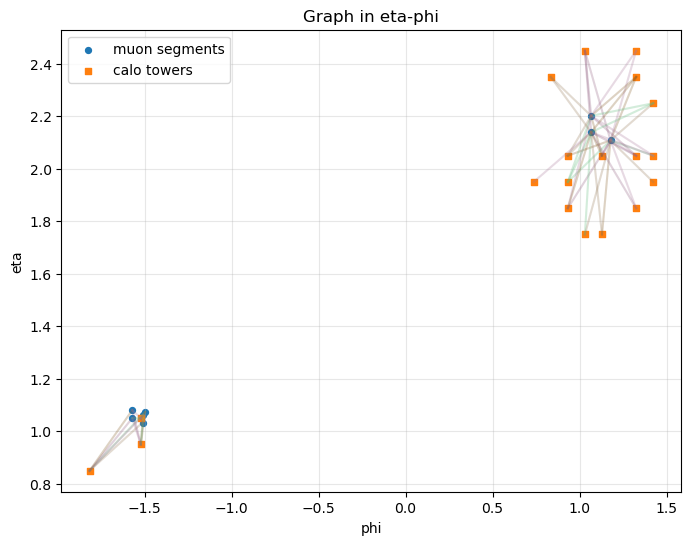

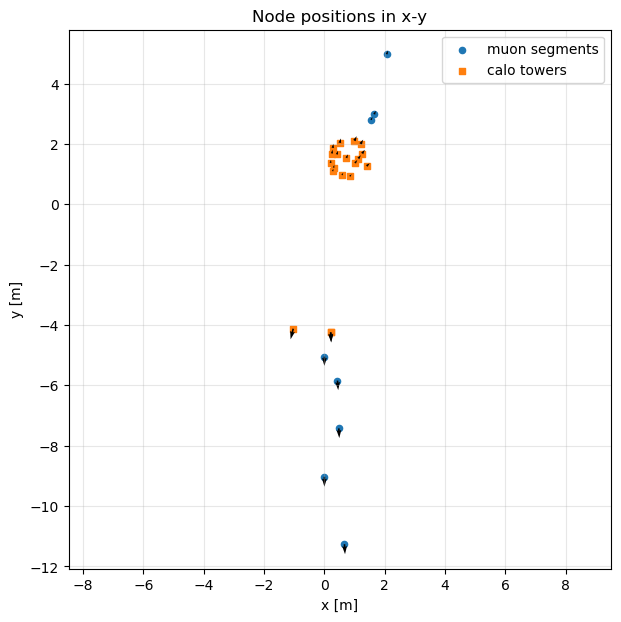

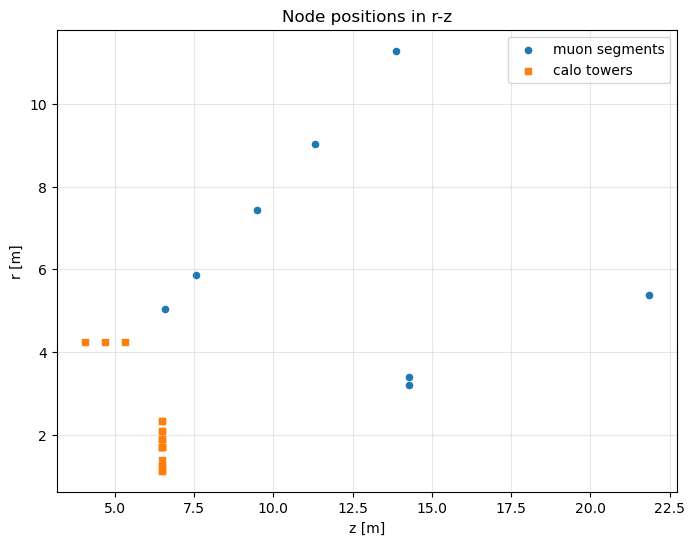

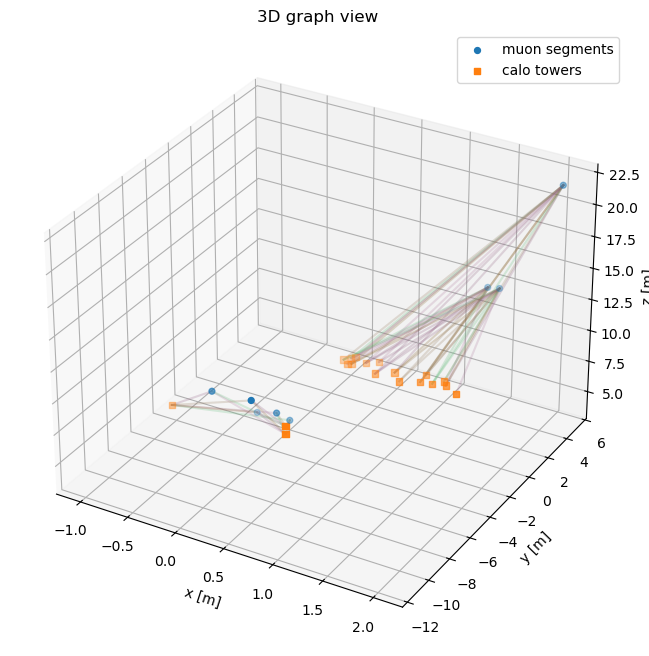

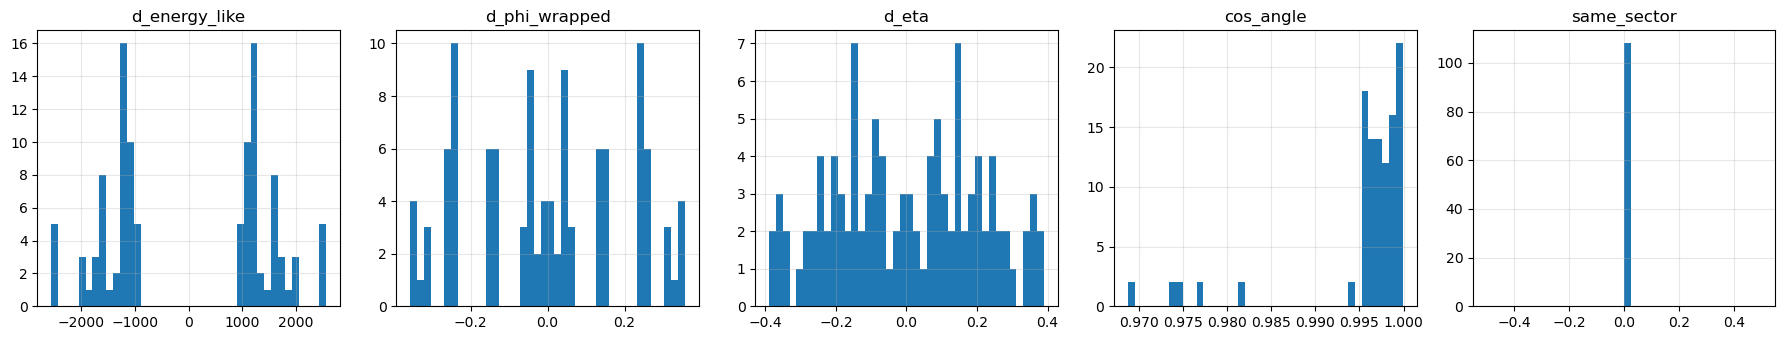

In [47]:
plot_eta_phi(ev)
plot_xy(ev)
plot_rz(ev)
plot_3d(ev)
plot_edge_attr_histograms(ev)

## 9. Debug helpers for missing events

In [48]:
def diagnose_event(evh):
    report = {'event_hash': evh}

    report['in_mu'] = evh in mu_ev_to_idx
    report['in_ca'] = evh in ca_ev_to_idx
    report['in_vx'] = evh in vx_ev_to_idx

    if report['in_vx']:
        vx_idxs = np.asarray(vx_ev_to_idx[evh], dtype=np.int64)
        report['pass_vertex'] = dvconv._event_passes_vertex_envelope(vx_td, vx_idxs, VERTEX_R_MAX_MM, VERTEX_Z_MAX_MM)
        report['y_vertex'] = dvconv._build_vertex_target(vx_td, vx_idxs)
    else:
        report['pass_vertex'] = False
        report['y_vertex'] = None

    if report['in_mu']:
        mu_idxs = np.asarray(mu_ev_to_idx[evh], dtype=np.int64)
        report['pass_segment_truth'] = dvconv._event_has_min_segments_and_truth(
            mu_td, mu_idxs, min_segments=2, require_truth=IS_MC, min_truth=2
        )
        mu_nodes = dvconv._build_muon_nodes(mu_td, mu_idxs)
        report['mu_nodes'] = None if mu_nodes is None else mu_nodes['x'].shape[0]
    else:
        report['pass_segment_truth'] = False
        report['mu_nodes'] = None
        mu_nodes = None

    if report['in_ca'] and mu_nodes is not None:
        ca_nodes = dvconv._build_calo_nodes(
            ca_td,
            np.asarray(ca_ev_to_idx[evh], dtype=np.int64),
            sector_mod=SECTOR_MOD,
            min_tower_energy_mev=MIN_TOWER_ENERGY_MEV,
            max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
            calo_r_max_mm=CALO_R_MAX_MM,
            calo_z_max_mm=CALO_Z_MAX_MM,
            seg_eta_list=mu_nodes['eta'],
            seg_phi_list=mu_nodes['phi'],
        )
        report['ca_nodes'] = None if ca_nodes is None else ca_nodes['x'].shape[0]
    else:
        report['ca_nodes'] = None

    return report

In [ ]:
# Example:
# diagnose_event(vx_keys[0])

## 10. Optional: browse several events quickly

In [49]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    def show_event(idx=0):
        clear_output(wait=True)
        display(slider)
        ev = passing_events[idx]
        print('event_hash:', ev['event_hash'])
        print('n_nodes:', ev['x'].shape[0], 'n_edges:', ev['edge_index'].shape[1])
        plot_eta_phi(ev, draw_edges=True, max_edges=500)
        plot_xy(ev, draw_dirs=False)

    slider = widgets.IntSlider(value=0, min=0, max=max(0, len(passing_events) - 1), step=1, description='event')
    widgets.interactive_output(show_event, {'idx': slider})
    display(slider)
except Exception as e:
    print('ipywidgets not available:', e)

IntSlider(value=0, description='event', max=797)

event_hash: (9, 2211895272948112)
n_nodes: 27 n_edges: 108


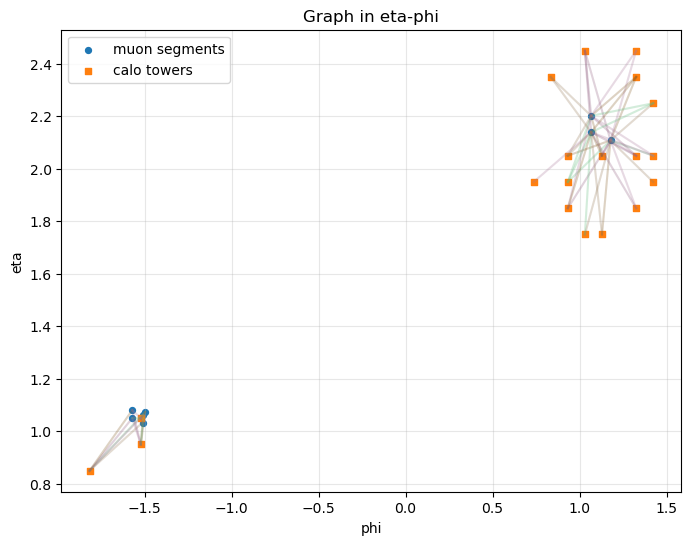

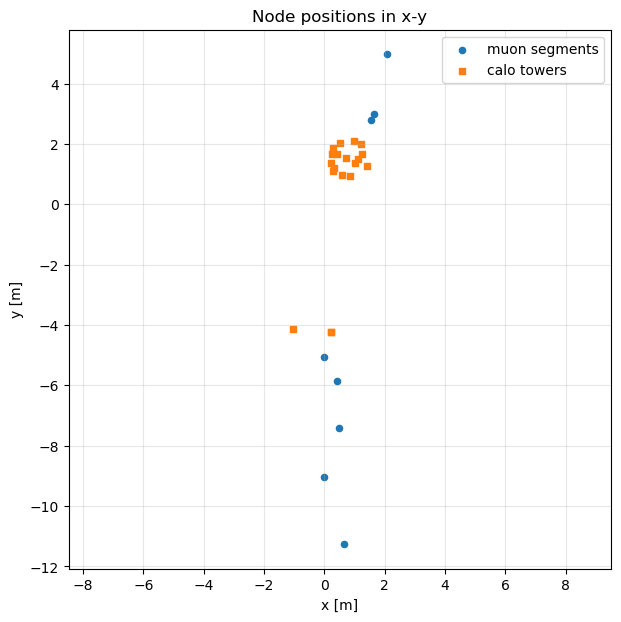

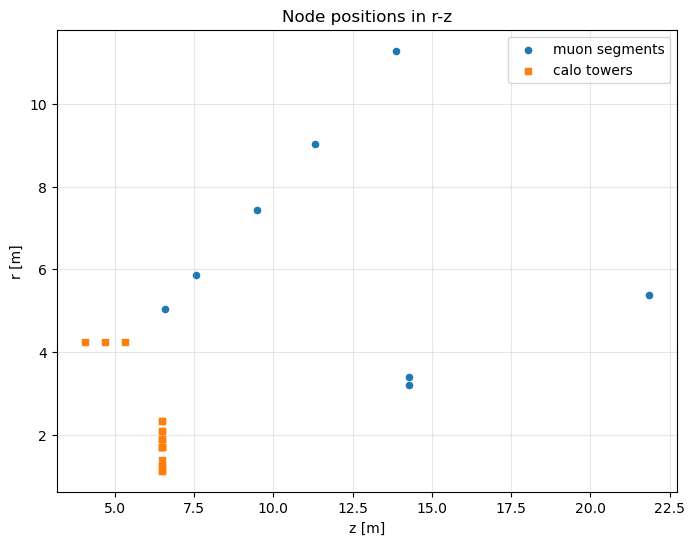

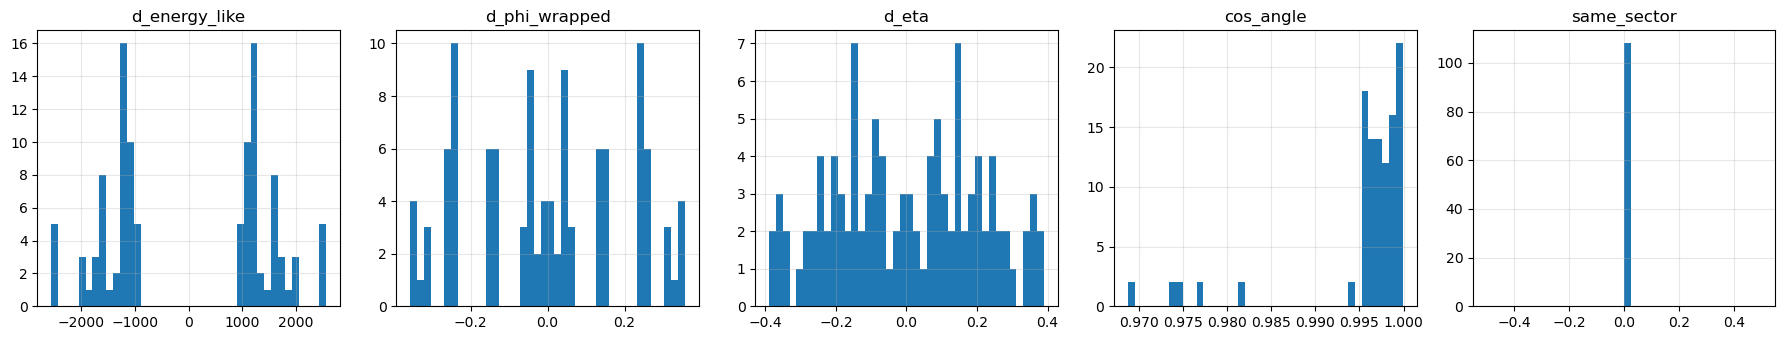

In [50]:
# simple manual browser without ipywidgets

EVENT_IDX = 0  # change this by hand

ev = passing_events[EVENT_IDX]
print('event_hash:', ev['event_hash'])
print('n_nodes:', ev['x'].shape[0], 'n_edges:', ev['edge_index'].shape[1])

plot_eta_phi(ev, draw_edges=True, max_edges=500)
plot_xy(ev, draw_dirs=False)
plot_rz(ev)
plot_edge_attr_histograms(ev)

In [51]:
def show_event(idx):
    ev = passing_events[idx]
    vx, vy, vz = ev['y_vertex']

    print('event index :', idx)
    print('event_hash  :', ev['event_hash'])
    print('vertex [m]  : x = %.4f  y = %.4f  z = %.4f' % (vx, vy, vz))

    print('n_nodes     :', ev['x'].shape[0])
    print('n_edges     :', ev['edge_index'].shape[1])
    print('n_mu_nodes  :', int(np.sum(ev['node_type'] == 0)))
    print('n_ca_nodes  :', int(np.sum(ev['node_type'] == 1)))

    # distance of nodes from vertex (useful debug)
    pos = ev['x'][:, :3]
    d = np.linalg.norm(pos - ev['y_vertex'], axis=1)
    print('node distance from vertex [m]:')
    print('  min = %.3f  mean = %.3f  max = %.3f' % (d.min(), d.mean(), d.max()))

    plot_eta_phi(ev, draw_edges=True, max_edges=500)
    plot_xy(ev, draw_dirs=False)
    plot_rz(ev)
    plot_edge_attr_histograms(ev)

event index : 0
event_hash  : (9, 2211895272948112)
vertex [m]  : x = 0.9861  y = 1.7591  z = 8.8329
n_nodes     : 27
n_edges     : 108
n_mu_nodes  : 8
n_ca_nodes  : 19
node distance from vertex [m]:
  min = 2.349  mean = 4.992  max = 13.960


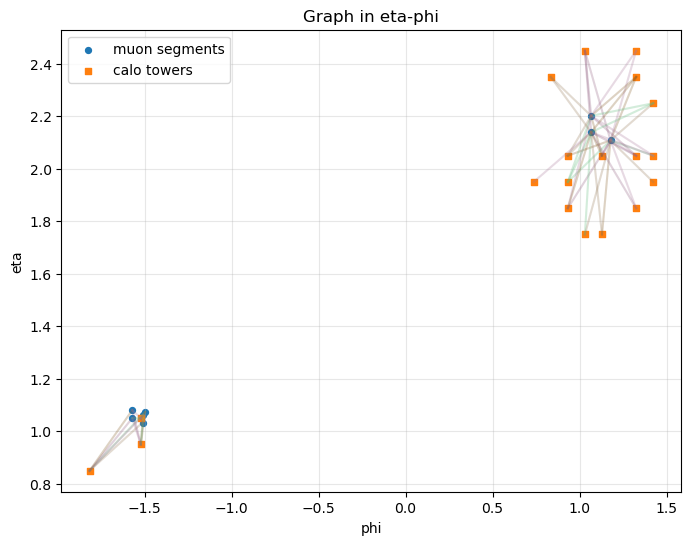

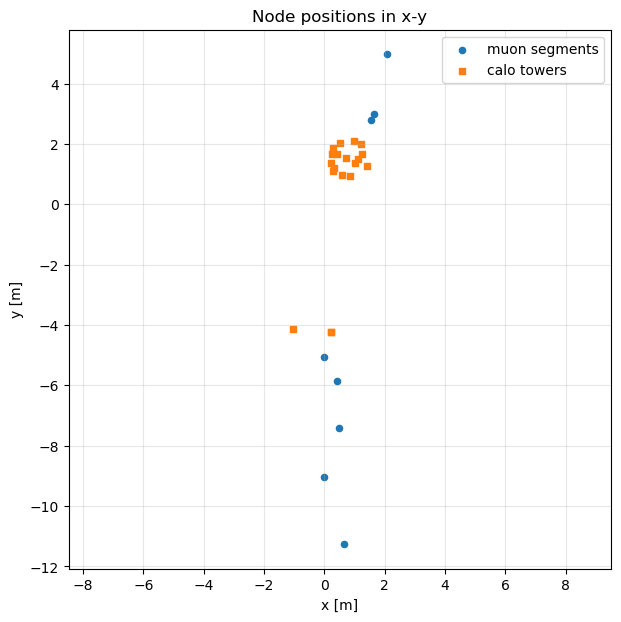

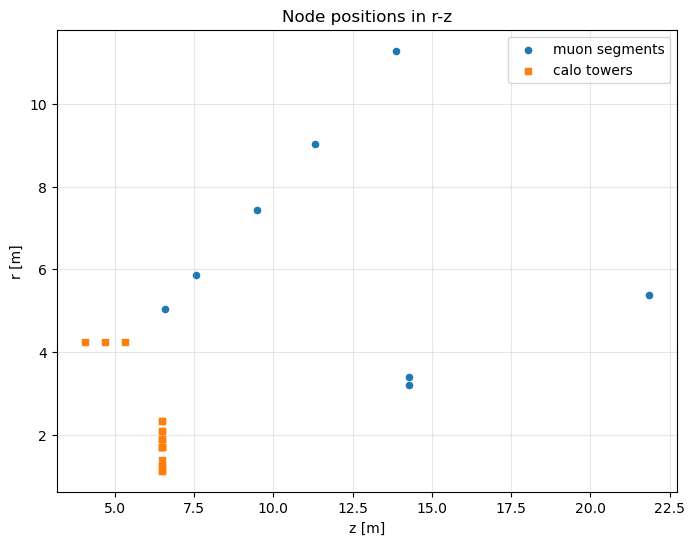

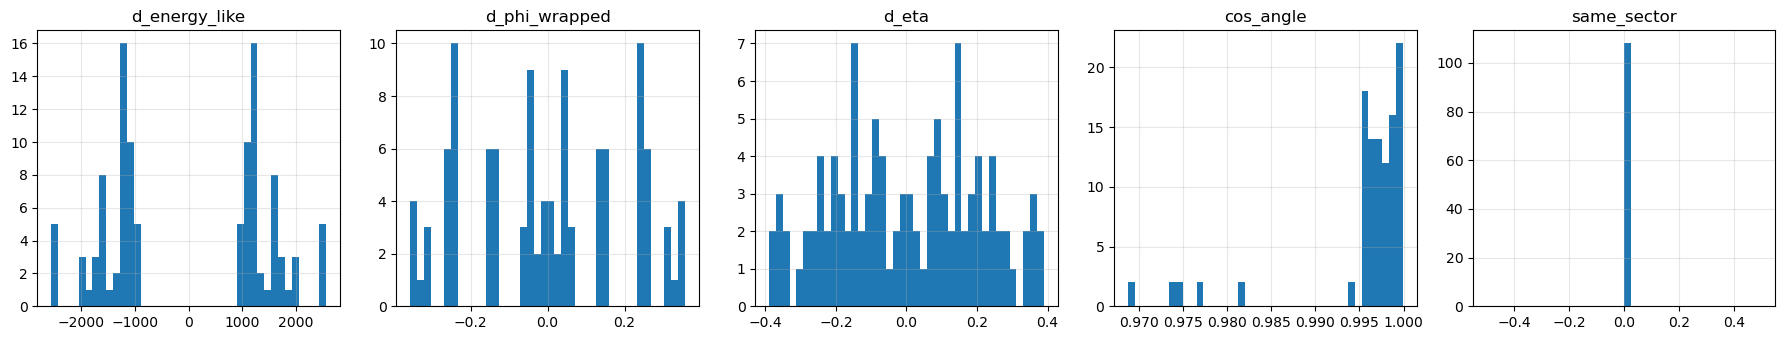

In [52]:
show_event(0)

event index : 1
event_hash  : (7, 2211895272948112)
vertex [m]  : x = 0.5881  y = -0.8601  z = 0.9410
n_nodes     : 16
n_edges     : 52
n_mu_nodes  : 6
n_ca_nodes  : 10
node distance from vertex [m]:
  min = 3.372  mean = 8.844  max = 18.309


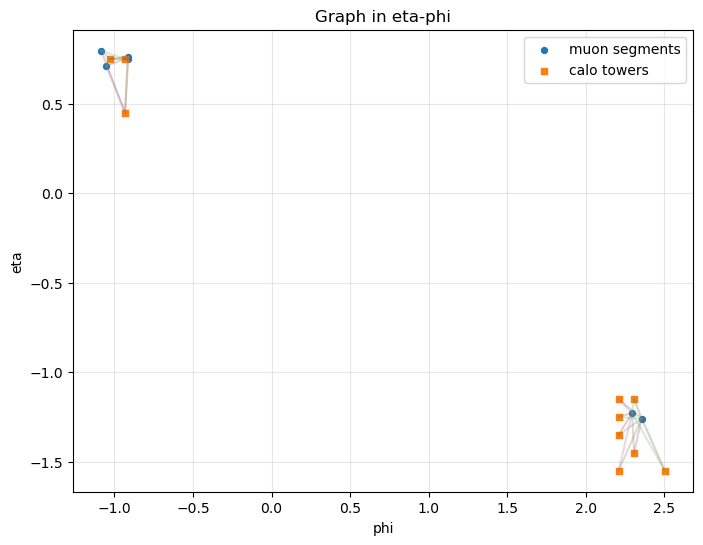

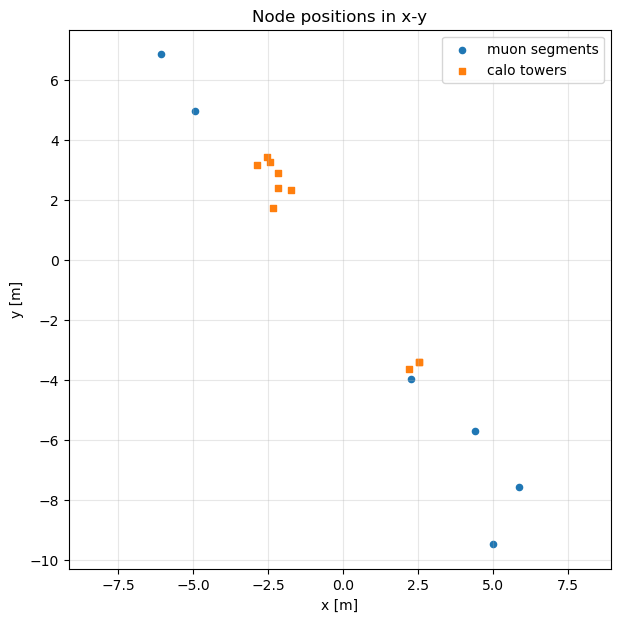

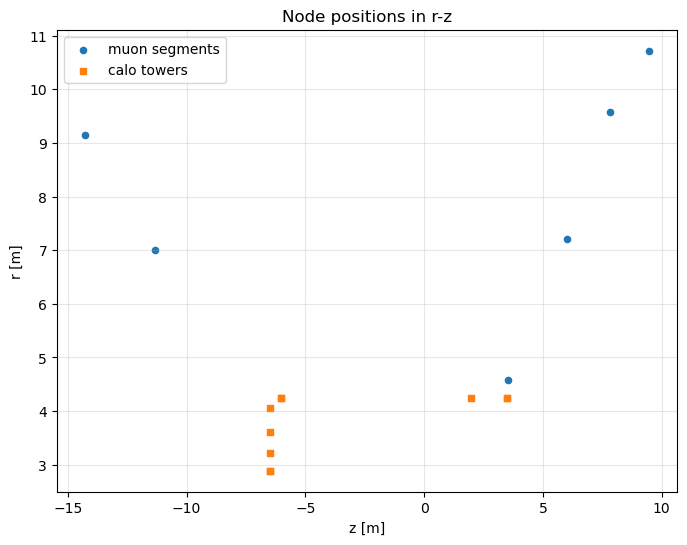

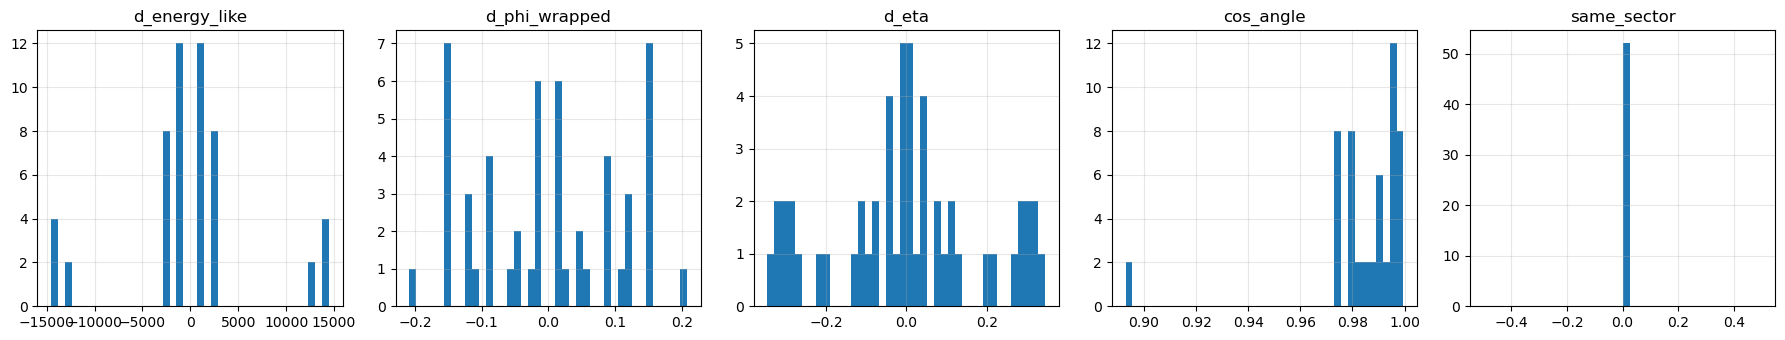

In [53]:
show_event(1)

event index : 2
event_hash  : (28, 2211895272948112)
vertex [m]  : x = 1.1897  y = -0.2594  z = -2.7663
n_nodes     : 16
n_edges     : 70
n_mu_nodes  : 4
n_ca_nodes  : 12
node distance from vertex [m]:
  min = 3.837  mean = 7.157  max = 20.712


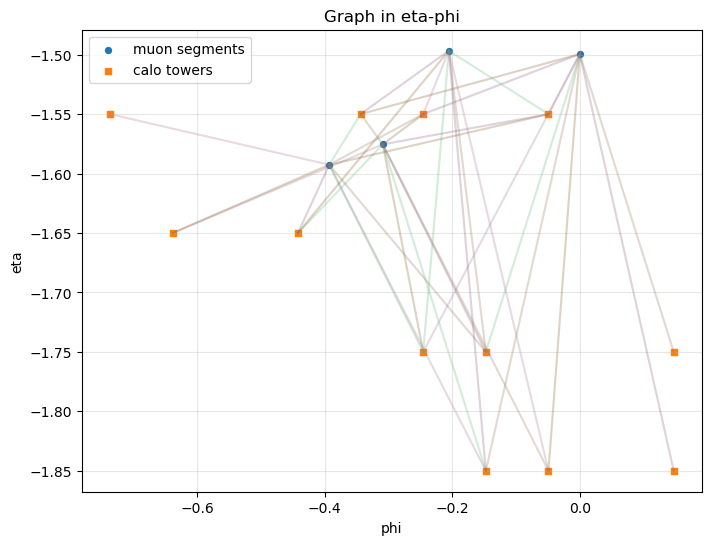

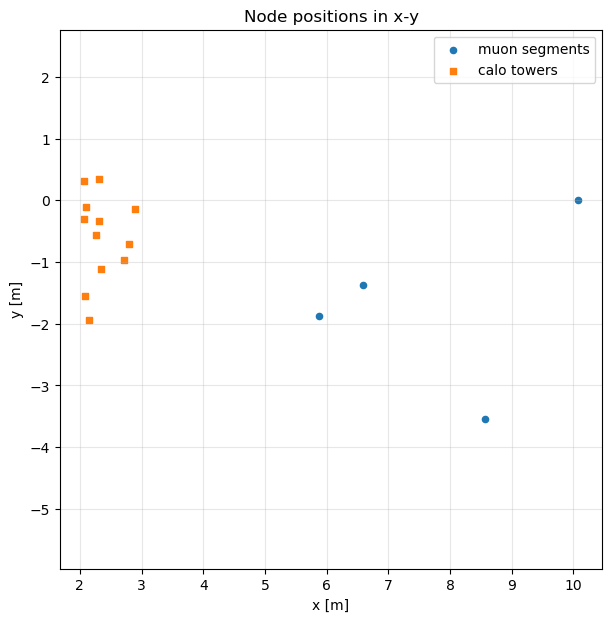

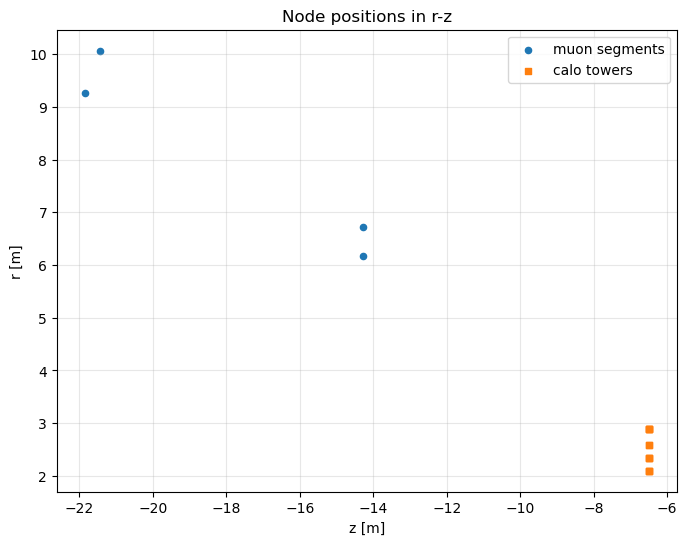

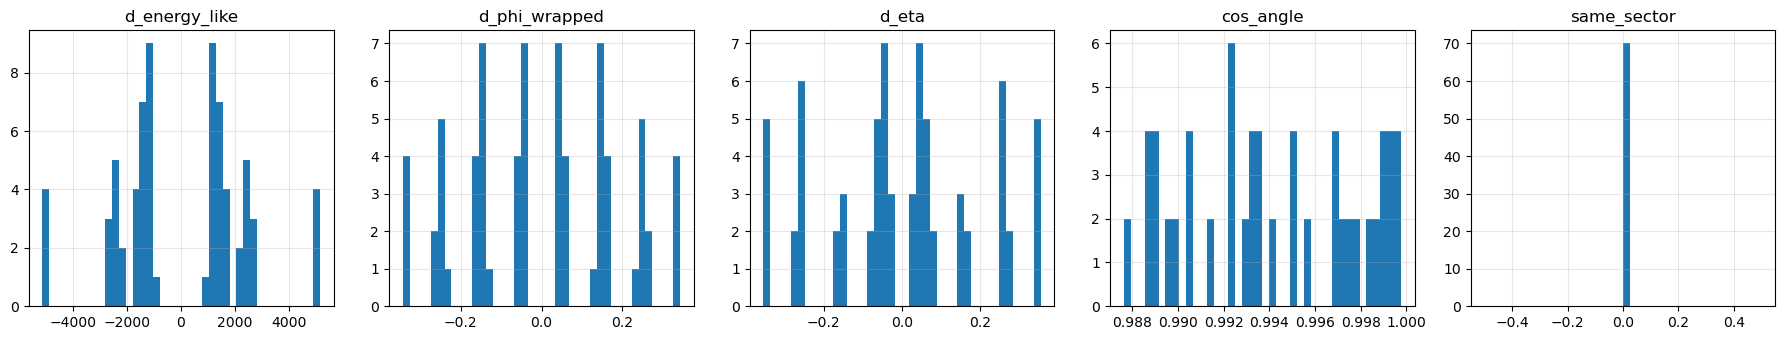

In [54]:
show_event(2)